# Clase 4 — Calibración y estrategia: del score a las decisiones de negocio
## Modelador de Riesgo de Crédito · Academia Bayes

**Demo en vivo con el dataset A — Banco Austral** (datos 100% sintéticos)

La clase 3 dejó un **scorecard de 8 variables** que ordena bien (Gini 0,757 /
0,698 / 0,675). Hoy respondemos las preguntas que vienen después del ranking:
¿la PD **dice la verdad**? ¿En qué **banda** vive cada cliente? ¿**Dónde**
cortamos — y qué clientes entran y salen con ese corte?

| # | Sección | ~min |
|---|---|---|
| 1 | Las clases 1–3 en celdas de referencia | 4 |
| 2 | El nivel: dónde clava y dónde miente | 5 |
| 3 | La tendencia central, desde la tabla de cosechas | 5 |
| 4 | El ajuste de intercepto: aproximado y exacto | 7 |
| 5 | La curva de calibración por deciles | 5 |
| 6 | Master scale: 8 bandas ancladas al PDO | 6 |
| 7 | La tabla de estrategia: aprobación vs pérdida esperada | 7 |
| 8 | Swap-set: a quién apruebo que antes rechazaba | 6 |
| 9 | Reject inference: la puerta completa | 3 |
| 10 | El atajo que NO existe (y el que viene: end-to-end en C6) | 3 |

> 🎯 **El principio de hoy**: el Gini mide si el score **ordena**; la calibración
> mide si la PD **dice la verdad**. Son promesas distintas, se validan distinto,
> y la segunda es la que mueve provisiones, precios y cupos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

BASE = "https://raw.githubusercontent.com/nexolabs-gh/datos-riesgo-credito/main"
PREFIJO = "austral"   # dataset A: Banco Austral

clientes       = pd.read_parquet(f"{BASE}/{PREFIJO}_clientes.parquet")
solicitudes    = pd.read_parquet(f"{BASE}/{PREFIJO}_solicitudes.parquet")
comportamiento = pd.read_parquet(f"{BASE}/{PREFIJO}_comportamiento.parquet")
bureau         = pd.read_parquet(f"{BASE}/{PREFIJO}_bureau.parquet")

print(f"solicitudes:    {solicitudes.shape[0]:,} filas × {solicitudes.shape[1]} columnas")
print(f"comportamiento: {comportamiento.shape[0]:,} filas × {comportamiento.shape[1]} columnas")

solicitudes:    32,301 filas × 10 columnas
comportamiento: 905,014 filas × 13 columnas


### Recordatorio: el diccionario de datos, a mano

Seguimos con las mismas cuatro tablas de Banco Austral, así que dejamos el
diccionario cargado otra vez. Cada variable que fabriquemos hoy nace de una
columna de estas tablas: si no sabes qué mide la columna, no puedes defender la
variable frente a un comité.

[`diccionario_austral.md`](https://github.com/nexolabs-gh/datos-riesgo-credito/blob/main/diccionario_austral.md) ·
la celda siguiente lo muestra completo y deja `mostrar_diccionario(...)` definida.

In [2]:
import urllib.request

from IPython.display import Markdown, display

URL_DICCIONARIO = f"{BASE}/diccionario_{PREFIJO}.md"
_DICCIONARIO = urllib.request.urlopen(URL_DICCIONARIO).read().decode("utf-8")


def mostrar_diccionario(tabla=None):
    """Muestra el diccionario de datos oficial; sin argumento, lo muestra completo."""
    if tabla is None:
        display(Markdown(_DICCIONARIO))
        return
    secciones = _DICCIONARIO.split("\n## ")[1:]
    elegidas = [s for s in secciones if s.lower().startswith(tabla.lower())]
    if not elegidas:
        disponibles = [s.split("(")[0].strip() for s in secciones]
        raise ValueError(f"No existe la tabla {tabla!r}. Disponibles: {disponibles}")
    display(Markdown("## " + elegidas[0]))


mostrar_diccionario()

# Diccionario de datos — Banco Austral

> Datos **100% sintéticos** generados para el curso *Modelador de Riesgo de Crédito*
> (Academia Bayes). Ninguna persona ni institución real está representada.

Panel mensual: 2023-07 a 2026-06. Montos en CLP.

## clientes (austral_clientes)
| Columna | Descripción |
|---|---|
| id_cliente | Identificador único del cliente |
| fecha_alta_cliente | Mes de alta en la institución (YYYY-MM) |
| edad | Edad en años al inicio del panel |
| sexo | M / F |
| region | Región de residencia (Chile) |
| estado_civil | soltero / casado / divorciado / viudo |
| nivel_educacional | básica / media / técnica / universitaria / postgrado |
| tipo_empleo | dependiente / independiente / jubilado |
| renta_liquida | Renta líquida mensual declarada (CLP). Puede venir vacía |
| n_dependientes | Número de cargas familiares |

## solicitudes (austral_solicitudes)
| Columna | Descripción |
|---|---|
| id_solicitud | Identificador de la solicitud |
| id_cliente | Cliente que solicita |
| fecha_solicitud | Mes de la solicitud (YYYY-MM) |
| monto_solicitado | Monto del crédito de consumo (CLP) |
| plazo_meses | Plazo en meses |
| destino | Uso declarado del crédito |
| canal | sucursal / web / app |
| aprobada | La solicitud fue aprobada y cursada |
| estado_actual | Estado del crédito **a la fecha de corte 2026-06** |
| marca_fraude | Fraude confirmado posteriormente |

## comportamiento_mensual (austral_comportamiento)
| Columna | Descripción |
|---|---|
| id_cliente, mes | Llave panel (YYYY-MM) |
| saldo_linea / cupo_linea | Saldo y cupo de línea de crédito (CLP) |
| saldo_tc / cupo_tc | Saldo y cupo de tarjeta de crédito (CLP) |
| saldo_consumo | Saldo vigente de créditos de consumo en cuotas |
| dias_mora | Días de mora del cliente al cierre del mes |
| monto_facturado / monto_pagado | Facturación y pago del mes |
| abonos_cuenta | Abonos totales a cuentas del cliente en el mes |
| saldo_ahorro | Saldo de ahorro/vista al cierre |
| n_productos | Número de productos vigentes |

## bureau_mensual (austral_bureau)
| Columna | Descripción |
|---|---|
| id_cliente, mes | Llave panel (YYYY-MM) |
| deuda_otras_inst | Deuda en otras instituciones (CLP) |
| n_otras_inst | Número de otras instituciones con deuda |
| consultas_mes | Consultas al bureau en el mes |
| peor_mora_sistema | Peor mora del cliente en el sistema (0/30/60/90) |


---
## 1. Las clases 1–3, en celdas de referencia

Las **tres celdas siguientes** son las clases 1, 2 y 3 comprimidas: target y
muestras, la fábrica de variables, y las herramientas de binning/WoE. Son la
misma receta de los demos anteriores — hoy no se narran, se ejecutan.

La **cuarta** celda merece una palabra: en vez de re-correr el stepwise completo
(eso fue la clase 3), **fijamos su resultado** — las 8 variables finales — y
re-ajustamos el modelo directo sobre ellas. Da exactamente los mismos
coeficientes: el stepwise termina, precisamente, ajustando ese logit.

In [3]:
# ---------- clase 1: target, población y muestras ----------
mora_w = comportamiento.pivot_table(index="id_cliente", columns="mes",
                                    values="dias_mora", aggfunc="first")
meses = list(mora_w.columns)
pos_mes = {m: k for k, m in enumerate(meses)}
M = mora_w.to_numpy()
fila_de = {c: k for k, c in enumerate(mora_w.index)}

cursadas = solicitudes[solicitudes["aprobada"]].copy()
cursadas["_t"] = cursadas["fecha_solicitud"].map(pos_mes)
cursadas["_i"] = cursadas["id_cliente"].map(fila_de)

peor = np.full(len(cursadas), np.nan)
for k, (i, t0) in enumerate(zip(cursadas["_i"], cursadas["_t"])):
    if t0 + 12 <= len(meses) - 1:
        peor[k] = M[i, t0 + 1: t0 + 13].max()
cursadas["peor_dpd_12m"] = peor
cursadas["malo"] = np.where(np.isnan(peor), np.nan, (peor >= 90).astype(float))
cursadas["indeterminado"] = (peor >= 30) & (peor < 90)

antig = clientes.set_index("id_cliente")["fecha_alta_cliente"].map(
    lambda s: (pd.Period(s, freq="M") - pd.Period(meses[0], freq="M")).n)

periodo = cursadas[cursadas["fecha_solicitud"].between("2024-07", "2025-06")]
periodo = periodo.sort_values("fecha_solicitud", kind="stable").drop_duplicates(
    "id_cliente", keep="first").copy()
periodo["antiguedad_meses"] = periodo["_t"] - periodo["id_cliente"].map(antig)
base = periodo[periodo["malo"].notna() & ~periodo["marca_fraude"]
               & (periodo["antiguedad_meses"] >= 6)].copy()

rng = np.random.default_rng(42)
base["muestra"] = np.where(base["fecha_solicitud"] <= "2025-02",
                           np.where(rng.random(len(base)) < 0.7, "DEV", "HO"), "OOT")
ttd_pob = cursadas[cursadas["fecha_solicitud"] >= "2025-07"].copy()
ttd_pob["antiguedad_meses"] = ttd_pob["_t"] - ttd_pob["id_cliente"].map(antig)
ttd_pob = ttd_pob[ttd_pob["antiguedad_meses"] >= 6]
ttd_pob["muestra"] = "TTD"
poblacion = pd.concat([base, ttd_pob], ignore_index=True)
print(poblacion["muestra"].value_counts().reindex(["DEV", "HO", "OOT", "TTD"]).to_string())

muestra
DEV    3501
HO     1465
OOT    2114
TTD    8585


In [4]:
# ---------- clase 2: panel ancho + fábrica declarativa + ratios ----------
def pivotar(df, columna):
    ancho = df.pivot_table(index="id_cliente", columns="mes", values=columna, aggfunc="first")
    return ancho.reindex(index=mora_w.index, columns=meses).to_numpy()

PANEL = {c: pivotar(comportamiento, c) for c in
         ["dias_mora", "saldo_linea", "cupo_linea", "saldo_tc", "cupo_tc", "saldo_consumo",
          "monto_pagado", "monto_facturado", "abonos_cuenta", "saldo_ahorro", "n_productos"]}
PANEL.update({c: pivotar(bureau, c) for c in
              ["deuda_otras_inst", "n_otras_inst", "consultas_mes", "peor_mora_sistema"]})
with np.errstate(divide="ignore", invalid="ignore"):
    PANEL["uso_linea"] = np.where(PANEL["cupo_linea"] > 0,
                                  PANEL["saldo_linea"] / PANEL["cupo_linea"], np.nan)
    PANEL["uso_tc"] = np.where(PANEL["cupo_tc"] > 0,
                               PANEL["saldo_tc"] / PANEL["cupo_tc"], np.nan)
PANEL["deuda_interna"] = PANEL["saldo_linea"] + PANEL["saldo_tc"] + PANEL["saldo_consumo"]
PANEL["deuda_total"] = PANEL["deuda_interna"] + PANEL["deuda_otras_inst"]
PANEL["en_mora"] = np.where(np.isnan(PANEL["dias_mora"]), np.nan,
                            (PANEL["dias_mora"] > 0).astype(float))
PANEL["en_mora_sistema"] = np.where(np.isnan(PANEL["peor_mora_sistema"]), np.nan,
                                    (PANEL["peor_mora_sistema"] > 0).astype(float))

def prom(V):  return np.nanmean(V, axis=1)
def vmax(V):  return np.nanmax(V, axis=1)
def suma(V):  return np.nansum(V, axis=1)
def delta(V): return V[:, -1] / np.maximum(V[:, 0], 1) - 1
def recencia(V):
    evento = np.nan_to_num(V, nan=0.0) > 0
    k = evento.shape[1]
    ultimo = k - 1 - np.argmax(evento[:, ::-1], axis=1)
    return np.where(evento.any(axis=1), k - ultimo, k + 1)
AGREGADORES = {"prom": prom, "max": vmax, "suma": suma, "delta": delta, "recencia": recencia}

def agregar_ventana(matriz, filas, t0s, k, funcion):
    salida = np.full(len(filas), np.nan)
    for t0 in np.unique(t0s):
        sel = t0s == t0
        salida[sel] = funcion(matriz[filas[sel], max(t0 - k, 0):t0])
    return salida

FABRICA = [
    ("dias_mora", "max", (3, 6, 12), "dias_mora_max_{k}m"),
    ("dias_mora", "prom", (3, 6, 12), "dias_mora_prom_{k}m"),
    ("en_mora", "suma", (3, 6, 12), "n_meses_mora_{k}m"),
    ("en_mora", "recencia", (12,), "meses_desde_mora_12m"),
    ("uso_linea", "prom", (3, 6, 12), "uso_linea_prom_{k}m"),
    ("uso_linea", "max", (3, 6, 12), "uso_linea_max_{k}m"),
    ("uso_tc", "prom", (3, 6, 12), "uso_tc_prom_{k}m"),
    ("uso_tc", "max", (3, 6, 12), "uso_tc_max_{k}m"),
    ("saldo_consumo", "prom", (3, 6, 12), "saldo_consumo_prom_{k}m"),
    ("saldo_consumo", "delta", (6, 12), "saldo_consumo_delta_{k}m"),
    ("deuda_interna", "prom", (3, 6, 12), "deuda_interna_prom_{k}m"),
    ("deuda_interna", "max", (3, 6, 12), "deuda_interna_max_{k}m"),
    ("deuda_total", "prom", (3, 6, 12), "deuda_total_prom_{k}m"),
    ("deuda_total", "delta", (6, 12), "deuda_total_delta_{k}m"),
    ("monto_pagado", "suma", (3, 6, 12), "pagos_{k}m"),
    ("monto_facturado", "suma", (3, 6, 12), "facturacion_{k}m"),
    ("abonos_cuenta", "prom", (3, 6, 12), "abonos_prom_{k}m"),
    ("abonos_cuenta", "delta", (6, 12), "abonos_delta_{k}m"),
    ("saldo_ahorro", "prom", (3, 6, 12), "saldo_ahorro_prom_{k}m"),
    ("n_productos", "prom", (3, 6, 12), "n_productos_prom_{k}m"),
    ("deuda_otras_inst", "prom", (3, 6, 12), "deuda_otras_prom_{k}m"),
    ("deuda_otras_inst", "max", (3, 6, 12), "deuda_otras_max_{k}m"),
    ("deuda_otras_inst", "delta", (6,), "delta_deuda_otras_{k}m"),
    ("n_otras_inst", "prom", (3, 6, 12), "n_otras_inst_prom_{k}m"),
    ("peor_mora_sistema", "max", (3, 6, 12), "peor_mora_sistema_{k}m"),
    ("en_mora_sistema", "suma", (3, 6, 12), "n_meses_mora_sistema_{k}m"),
    ("consultas_mes", "suma", (3, 6, 12), "consultas_{k}m"),
    ("consultas_mes", "recencia", (12,), "meses_desde_consulta_12m"),
]
META = ["id_solicitud", "id_cliente", "fecha_solicitud", "_t", "_i",
        "muestra", "malo", "indeterminado", "peor_dpd_12m"]

filas_p, t0s_p = poblacion["_i"].to_numpy(), poblacion["_t"].to_numpy()
X = poblacion[META + ["antiguedad_meses", "monto_solicitado", "plazo_meses",
                      "destino", "canal"]].copy()
for serie, agg, ventanas, plantilla in FABRICA:
    for k in ventanas:
        X[plantilla.format(k=k)] = agregar_ventana(PANEL[serie], filas_p, t0s_p, k,
                                                   AGREGADORES[agg])
t_ult = np.maximum(t0s_p - 1, 0)
for serie in ["dias_mora", "saldo_linea", "cupo_linea", "saldo_tc", "cupo_tc",
              "saldo_consumo", "saldo_ahorro", "deuda_otras_inst", "n_productos",
              "peor_mora_sistema", "uso_linea", "uso_tc"]:
    X[f"{serie}_ult"] = PANEL[serie][filas_p, t_ult]

ingreso = X["abonos_prom_6m"].to_numpy()
deuda_ult = (X["saldo_linea_ult"] + X["saldo_tc_ult"]
             + X["saldo_consumo_ult"] + X["deuda_otras_inst_ult"])
X["carga_financiera"] = deuda_ult / np.maximum(ingreso, 1)
X["pago_sobre_fact_6m"] = X["pagos_6m"] / np.maximum(X["facturacion_6m"], 1)
X["pago_sobre_fact_12m"] = X["pagos_12m"] / np.maximum(X["facturacion_12m"], 1)
X["deuda_int_sobre_sistema"] = (X["saldo_linea_ult"] + X["saldo_tc_ult"]
                                + X["saldo_consumo_ult"]) / np.maximum(deuda_ult, 1)
X["ahorro_sobre_ingreso"] = X["saldo_ahorro_ult"] / np.maximum(ingreso, 1)
X["monto_sobre_ingreso"] = X["monto_solicitado"] / np.maximum(ingreso, 1)
X["cuota_est_sobre_ingreso"] = (X["monto_solicitado"] / X["plazo_meses"]) / np.maximum(ingreso, 1)
X = X.merge(clientes[["id_cliente", "edad", "sexo", "region", "estado_civil",
                      "nivel_educacional", "tipo_empleo", "renta_liquida",
                      "n_dependientes"]], on="id_cliente", how="left")
X["renta_vs_abonos"] = X["renta_liquida"] / np.maximum(ingreso, 1)

predictoras = [c for c in X.columns if c not in META]
filtro = X["malo"].notna() & ~X["indeterminado"]
dev = X[(X["muestra"] == "DEV") & filtro]
ho  = X[(X["muestra"] == "HO") & filtro]
oot = X[(X["muestra"] == "OOT") & filtro]
ttd = X[X["muestra"] == "TTD"]
print(f"MATRIZ: {len(X):,} filas × {len(predictoras)} candidatas")
print(f"DEV={len(dev):,} ({dev['malo'].mean():.1%} malos) · HO={len(ho):,} · "
      f"OOT={len(oot):,} · TTD={len(ttd):,}")

MATRIZ: 15,665 filas × 108 candidatas
DEV=3,322 (5.0% malos) · HO=1,397 · OOT=2,004 · TTD=8,585


In [5]:
# ---------- clase 2/3: binning con `ref` + tabla WoE ----------
def binear(x, bins=5, umbral_moda=0.35, ref=None):
    """Binning del curso. Con `ref`, los cortes se calculan en `ref` y se aplican a `x`."""
    x = pd.Series(x).reset_index(drop=True)
    base_b = x if ref is None else pd.Series(ref).reset_index(drop=True)
    if base_b.dtype == object or isinstance(base_b.dtype, pd.CategoricalDtype):
        return x.astype(str).where(x.notna(), "MISSING"), None
    if base_b.nunique(dropna=True) <= bins:
        return x.astype(str).where(x.notna(), "MISSING"), None
    moda = base_b.mode().iloc[0]
    frac_moda = (base_b == moda).mean()
    resto = base_b[base_b != moda] if frac_moda > umbral_moda else base_b
    cortes = np.unique(np.nanquantile(resto.dropna(), np.linspace(0, 1, bins + 1)))
    if len(cortes) < 3:
        return x.astype(str).where(x.notna(), "MISSING"), None
    cortes[0], cortes[-1] = -np.inf, np.inf
    categorias = pd.cut(x, cortes)
    orden = [str(c) for c in categorias.cat.categories]
    etiquetas = categorias.astype(str)
    if frac_moda > umbral_moda:
        etiquetas = etiquetas.where(x != moda, f"= {moda:.4g}")
        orden = [f"= {moda:.4g}"] + orden
    return etiquetas.where(x.notna(), "MISSING"), orden + ["MISSING"]


def tabla_woe(x, y, bins=5, ref=None):
    """Tabla WoE de una variable y su IV (convención: target 1 = malo)."""
    etiquetas, orden = binear(x, bins, ref=ref)
    tab = pd.DataFrame({"bin": etiquetas.values, "y": pd.Series(y).values}) \
            .groupby("bin")["y"].agg(["count", "sum"])
    tab.columns = ["n", "malos"]
    if orden:
        tab = tab.reindex([o for o in orden if o in tab.index])
    tab["buenos"] = tab["n"] - tab["malos"]
    tab["tasa_malos"] = tab["malos"] / tab["n"]
    p_malos  = (tab["malos"] + 0.5) / (tab["malos"].sum() + 0.5 * len(tab))
    p_buenos = (tab["buenos"] + 0.5) / (tab["buenos"].sum() + 0.5 * len(tab))
    tab["woe"] = np.log(p_buenos / p_malos)
    tab["iv_aporte"] = (p_buenos - p_malos) * tab["woe"]
    return tab, float(tab["iv_aporte"].sum())

In [6]:
# ---------- clase 3 comprimida: el modelo final y el scorecard ----------
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

# Las 8 variables que dejó el stepwise de la clase 3 (demo_c3_banco_austral.ipynb)
ELEGIDAS = ["uso_linea_prom_12m", "meses_desde_mora_12m", "uso_tc_prom_12m",
            "deuda_interna_max_3m", "antiguedad_meses", "deuda_otras_prom_12m",
            "carga_financiera", "uso_tc_prom_3m"]

MAPAS = {v: tabla_woe(dev[v], dev["malo"])[0]["woe"] for v in ELEGIDAS}

def a_woe(df, variables):
    """Transforma `df` al WoE de DEV: binea con cortes de DEV y mapea su WoE."""
    F = pd.DataFrame(index=range(len(df)))
    for v in variables:
        etiquetas, _ = binear(df[v], ref=dev[v])
        F[v] = etiquetas.map(MAPAS[v]).fillna(0.0).values
    return F

modelo = sm.Logit(dev["malo"].values,
                  sm.add_constant(a_woe(dev, ELEGIDAS), has_constant="add")
                  ).fit(disp=0, maxiter=200)
assert (modelo.params.drop("const") < 0).all(), "signos: revisar antes de seguir"

# Scaling PDO de la clase 3
PDO, SCORE_BASE, ODDS_BASE = 20, 600, 50
factor = PDO / np.log(2)
offset = SCORE_BASE - factor * np.log(ODDS_BASE)

def pd_de(df):
    """PD cruda del modelo (WoE y cortes de DEV, como producción)."""
    return np.asarray(modelo.predict(sm.add_constant(a_woe(df, ELEGIDAS),
                                                     has_constant="add")))

def score_desde_pd(p):
    """Score PDO desde una PD, con clip bilateral (evita ±inf en los bordes)."""
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    return offset + factor * np.log((1 - p) / p)

gini_dev = 2 * roc_auc_score(dev["malo"], pd_de(dev)) - 1
print(f"modelo de la clase 3 re-ajustado: {len(ELEGIDAS)} variables · "
      f"Gini DEV {gini_dev:.3f} (clase 3: 0.757) · factor {factor:.3f} · offset {offset:.2f}")

modelo de la clase 3 re-ajustado: 8 variables · Gini DEV 0.757 (clase 3: 0.757) · factor 28.854 · offset 487.12


---
## 2. El nivel: dónde clava y dónde miente

La pregunta de hoy no es «¿ordena?» (eso ya lo medimos): es **«¿la PD promedio
se parece a la tasa de malos real?»**. Comparamos, muestra por muestra, la PD
media del modelo contra lo observado.

Spoiler de por qué DEV va a clavar: el intercepto de máxima verosimilitud
**absorbe la tasa de malos de su propia muestra**. En DEV, la media de las PD
predichas es exactamente la tasa observada — siempre, por construcción. El
mérito (o la mentira) se mide **fuera** de DEV.

In [7]:
MUESTRAS = {"DEV": dev, "HO": ho, "OOT": oot, "TTD": ttd}
PD_RAW = {m: pd_de(df) for m, df in MUESTRAS.items()}

nivel = pd.DataFrame({
    "pd_media": {m: PD_RAW[m].mean() for m in MUESTRAS},
    "tasa_observada": {m: (MUESTRAS[m]["malo"].mean() if m != "TTD" else np.nan)
                       for m in MUESTRAS}})
nivel["sesgo_pts"] = (nivel["pd_media"] - nivel["tasa_observada"]) * 100
print(nivel.round(4).to_string())

assert abs(nivel.loc["DEV", "pd_media"] - nivel.loc["DEV", "tasa_observada"]) < 1e-6, \
    "en DEV la media de PD DEBE ser la tasa observada (intercepto MLE)"
print("\n✅ DEV clava por construcción — el diagnóstico honesto está en HO y OOT")

     pd_media  tasa_observada  sesgo_pts
DEV    0.0497          0.0497    -0.0000
HO     0.0517          0.0558    -0.4166
OOT    0.0519          0.0594    -0.7488
TTD    0.0579             NaN        NaN

✅ DEV clava por construcción — el diagnóstico honesto está en HO y OOT


**Lectura:**

- **DEV: 4,97% vs 4,97%.** Cero mérito: es la definición del intercepto MLE.
- **HO: 5,17% vs 5,58% (−0,42 pts).** Mismos meses, clientes nuevos — ya asoma
  el sesgo.
- **OOT: 5,19% vs 5,94% (−0,75 pts).** Meses posteriores: el modelo **subestima**
  el riesgo. La cartera se deterioró dentro de la ventana y el intercepto quedó
  anclado al pasado.
- **TTD: PD media 5,79%, observado no existe aún.** La bandeja de hoy ya *parece*
  más riesgosa (el mix se movió), pero su verdad se sabrá en 12 meses.

> ⚠️ Si mañana calculamos provisiones con estas PD, provisionamos de menos. Ese
> es el costo de confundir «ordena bien» con «dice la verdad».

---
## 3. La tendencia central, desde la tabla de cosechas

¿A qué nivel anclamos la PD? No al de DEV (una foto de 8 cosechas): a la
**tendencia central (TC)** — el ancla de nivel para la cartera. La herramienta
es la primera que construimos en este curso: la **tabla de cosechas** de la
clase 1, sobre la población good/bad completa (las 12 cosechas maduras).

> ⚖️ Honestidad de nombre: una *long-run average* de verdad exige historia que
> cubra ciclo (5+ años) y definiciones estables; aquí tenemos **12 cosechas de
> un año**. Esta TC es «el ancla que la ventana disponible permite» — se declara
> así, y se revisa cuando haya más historia.

In [8]:
gb = X[X["malo"].notna() & ~X["indeterminado"]]
tasa_cosecha = gb.groupby("fecha_solicitud")["malo"].agg(["mean", "count", "sum"])
tasa_cosecha.columns = ["tasa", "n", "malos"]
print(tasa_cosecha.round(4).to_string())

TC = float(tasa_cosecha["tasa"].mean())
tc_ponderada = float(gb["malo"].mean())
print(f"\nTC promedio simple de cosechas : {TC:.4f}  ← la del curso")
print(f"TC ponderada por volumen       : {tc_ponderada:.4f}")
print(f"tasa de DEV (el ancla implícita del modelo): {dev['malo'].mean():.4f}")

                   tasa    n  malos
fecha_solicitud                    
2024-07          0.0524  592   31.0
2024-08          0.0550  618   34.0
2024-09          0.0398  603   24.0
2024-10          0.0410  585   24.0
2024-11          0.0686  583   40.0
2024-12          0.0484  640   31.0
2025-01          0.0523  554   29.0
2025-02          0.0551  544   30.0
2025-03          0.0697  488   34.0
2025-04          0.0497  503   25.0
2025-05          0.0594  505   30.0
2025-06          0.0591  508   30.0

TC promedio simple de cosechas : 0.0542  ← la del curso
TC ponderada por volumen       : 0.0538
tasa de DEV (el ancla implícita del modelo): 0.0497


**Dos decisiones que se declaran (no se esconden):**

1. **Promedio simple, no ponderado**: cada cosecha pesa igual — mirada de ciclo
   (*through-the-cycle*). El ponderado seguiría el mix de volumen de la ventana.
   Aquí casi no cambia (5,42% vs 5,38%); la disciplina de declararlo, sí.
2. **La TC se estima sobre la población good/bad**, consistente con el target
   (los indeterminados están fuera del numerador y del denominador, igual que en
   el entrenamiento).

En la práctica la TC además incorpora juicio experto y expectativa macro — es un
**parámetro de negocio con dueño**, no un output del notebook. Nuestro 5,42%
contra el 4,97% de DEV dice: el modelo nació ~9% más optimista que el ciclo.

> 🔍 **Un fino de honestidad metodológica** (así se declara en un informe serio):
> la TC usa las 12 cosechas maduras — **incluidas las de OOT** — porque así se
> fija una *long-run average* en la práctica: con toda la historia disponible.
> El precio de esa decisión: cuando más abajo veamos que el nivel calibrado
> «mejora» en OOT, eso es **coherencia con el ancla** (OOT aporta un tercio de
> las cosechas de la TC), no una validación independiente. La validación
> independiente del nivel es el **backtesting sobre datos futuros** — clase 5.

---
## 4. El ajuste de intercepto: aproximado y exacto

Mecánica: sumar una constante $\delta$ al logit de cada cliente.

$$\text{PD}^{cal}_i = \sigma\big(\text{logit}(\text{PD}_i) + \delta\big)$$

**La aproximación clásica** (Siddiqi) trabaja con las medias:

$$\delta \approx \text{logit}(\text{TC}) - \text{logit}(\bar{\text{PD}}_{DEV})$$

**La exacta** exige que la media de las PD ajustadas sea la TC:

$$\frac{1}{n}\sum_i \sigma\big(\text{logit}(\text{PD}_i) + \delta\big) = \text{TC}$$

— una ecuación en $\delta$ sin solución cerrada, pero monótona: `scipy.optimize.brentq`
la resuelve en milisegundos. La diferencia entre ambas es **Jensen**: la media de
la sigmoide no es la sigmoide de la media, y con PD dispersas (las nuestras van
de 0,05% a 30%) el atajo se queda corto.

In [9]:
from scipy.optimize import brentq
from scipy.special import expit, logit

assert 0 < TC < 1, f"TC fuera de (0,1): {TC}"
media_dev = PD_RAW["DEV"].mean()
delta_aprox = float(logit(TC) - logit(media_dev))

lp_dev = logit(np.clip(PD_RAW["DEV"], 1e-12, 1 - 1e-12))
delta = float(brentq(lambda d: expit(lp_dev + d).mean() - TC, -5, 5, xtol=1e-12))

print(f"delta aproximado (logit de medias): {delta_aprox:+.4f}")
print(f"delta exacto (brentq)             : {delta:+.4f}")

PD_CAL, SCORE_CAL = {}, {}
for m in MUESTRAS:
    lp = logit(np.clip(PD_RAW[m], 1e-12, 1 - 1e-12))
    PD_CAL[m] = expit(lp + delta)
    SCORE_CAL[m] = score_desde_pd(PD_CAL[m])

assert abs(PD_CAL["DEV"].mean() - TC) < 1e-9, "el delta exacto debe dejar la media EN la TC"
print(f"\n✅ PD media de DEV calibrada: {PD_CAL['DEV'].mean():.4f} = TC")

delta aproximado (logit de medias): +0.0924
delta exacto (brentq)             : +0.1115

✅ PD media de DEV calibrada: 0.0542 = TC


In [10]:
# el nivel, antes y después
nivel["pd_calibrada"] = {m: PD_CAL[m].mean() for m in MUESTRAS}
nivel["sesgo_cal_pts"] = (nivel["pd_calibrada"] - nivel["tasa_observada"]) * 100
print(nivel[["pd_media", "pd_calibrada", "tasa_observada",
             "sesgo_pts", "sesgo_cal_pts"]].round(4).to_string())

# y la promesa de la clase: el ranking NO se toca
gini_antes = 2 * roc_auc_score(oot["malo"], PD_RAW["OOT"]) - 1
gini_despues = 2 * roc_auc_score(oot["malo"], PD_CAL["OOT"]) - 1
assert abs(gini_antes - gini_despues) < 1e-12
print(f"\n✅ Gini OOT antes {gini_antes:.4f} = después {gini_despues:.4f}: "
      "sumar una constante al logit no cambia el orden")

     pd_media  pd_calibrada  tasa_observada  sesgo_pts  sesgo_cal_pts
DEV    0.0497        0.0542          0.0497    -0.0000         0.4546
HO     0.0517        0.0563          0.0558    -0.4166         0.0476
OOT    0.0519        0.0565          0.0594    -0.7488        -0.2871
TTD    0.0579        0.0631             NaN        NaN            NaN

✅ Gini OOT antes 0.6750 = después 0.6750: sumar una constante al logit no cambia el orden


**Lectura del antes/después:**

- **HO: −0,42 → +0,05 pts.** El ajuste prácticamente clava el nivel.
- **OOT: −0,75 → −0,29 pts.** Mejora — recordando el fino de la sección 3: como
  las cosechas de OOT están dentro de la TC, esto es coherencia con el ancla,
  no un test independiente. Y queda residuo: la hipótesis de trabajo es
  **deriva reciente** (la cartera siguió moviéndose y una constante no persigue
  tendencias), aunque con este n el residuo también cabe en el ruido — se
  declara como hipótesis y se vigila (backtesting, clase 5).
- **DEV queda en 5,42% contra 4,97% observado**: correcto — ya no está anclado a
  su muestra sino a la TC. Ese «desajuste» en DEV es intencional.

> 🧭 El mismo mecanismo funciona al revés: si el comité fija una TC más severa
> (ciclo malo esperado), δ se recalcula y toda la escala de PD se desplaza —
> documentado, reversible, sin re-entrenar nada.

---
## 5. La curva de calibración por deciles

El nivel promedio puede calzar y aun así mentir **por tramos** (optimista en un
extremo, pesimista en el otro, promediando bien). La curva de calibración revisa
tramo a tramo: ordenar por PD calibrada, partir en deciles, y en cada uno
comparar la PD predicha promedio contra la tasa de malos observada.

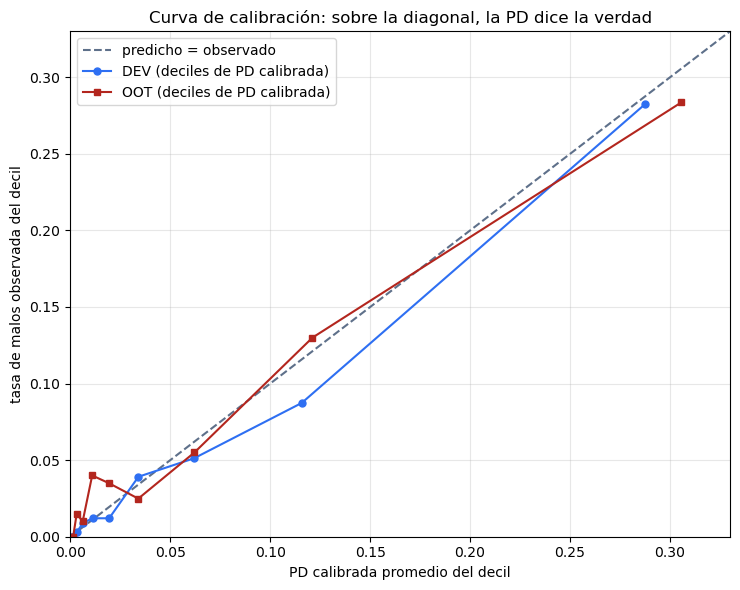

   pd_predicha  tasa_observada    n
g                                  
0       0.0005          0.0000  201
1       0.0014          0.0000  200
2       0.0032          0.0150  200
3       0.0062          0.0100  201
4       0.0110          0.0400  200
5       0.0193          0.0350  200
6       0.0340          0.0249  201
7       0.0621          0.0550  200
8       0.1211          0.1300  200
9       0.3056          0.2836  201


In [11]:
def curva_calibracion(pd_pred, malo, n_grupos=10):
    grupo = pd.qcut(pd_pred, n_grupos, labels=False, duplicates="drop")
    return pd.DataFrame({"pred": pd_pred, "obs": np.asarray(malo, dtype=float),
                         "g": grupo}).groupby("g").agg(
        pd_predicha=("pred", "mean"), tasa_observada=("obs", "mean"), n=("obs", "size"))

fig, ax = plt.subplots(figsize=(7.5, 6))
lim = 0.33
ax.plot([0, lim], [0, lim], ls="--", color="#5E708A", label="predicho = observado")
for nombre, color, marca in [("DEV", "#2E6FF2", "o"), ("OOT", "#B3261E", "s")]:
    c = curva_calibracion(PD_CAL[nombre], MUESTRAS[nombre]["malo"].values)
    ax.plot(c["pd_predicha"], c["tasa_observada"], color=color, marker=marca,
            ms=5, label=f"{nombre} (deciles de PD calibrada)")
ax.set_xlabel("PD calibrada promedio del decil")
ax.set_ylabel("tasa de malos observada del decil")
ax.legend(); ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_title("Curva de calibración: sobre la diagonal, la PD dice la verdad")
plt.tight_layout(); plt.show()

print(curva_calibracion(PD_CAL["OOT"], oot["malo"].values).round(4).to_string())

**Cómo leerla sin sobre-reaccionar:**

- Ambas curvas **siguen la diagonal en el grueso del rango**: el WoE capturó la
  no linealidad y el δ puso el nivel.
- El decil de mayor riesgo concentra la evidencia (OOT: predicho 30,6% vs
  observado 28,4%): ahí viven la mitad de los malos.
- Los deciles bajos zigzaguean con **n ≈ 200 por decil**: un decil con 2%
  observado son *4 clientes*. Pero cuidado con despachar todo como ruido: en
  OOT hay un decil bajo con ~1,1% predicho y ~4% observado — 8 malos donde se
  esperaban ~2. ¿Ruido o un tramo descalibrado? **A ojo no se decide**: ese es
  exactamente el trabajo del test binomial por banda de la clase 5.

> 📏 La versión con rigor — test binomial por banda, Hosmer-Lemeshow, semáforos —
> es materia de la clase 5. Hoy: ojo entrenado sobre la curva.

---
## 6. Master scale: 8 bandas ancladas al PDO

Nadie gobierna 10.000 PD distintas: se gobiernan **bandas con nombre**. Y como
nuestro scaling ya fijó PDO = 20, la escala sale gratis: **una banda de 20
puntos duplica las odds exactamente**. Ancla: 600 puntos = odds 50:1.

8 bandas: **A1** (≥ 660) … **E** (< 540). La validación no es teórica: se mira
la **tasa observada** por banda — debe escalar monótona, sin bandas vacías ni
concentradas.

In [12]:
CORTES_BANDA = [540, 560, 580, 600, 620, 640, 660]
ETIQUETAS = ["E", "D", "C2", "C1", "B2", "B1", "A2", "A1"]      # peor → mejor

def banda_de(score):
    # right=False: un score exactamente en el corte cae en la banda SUPERIOR,
    # coherente con las etiquetas "540-560" / ">= 660" y con `score >= cutoff`
    return pd.cut(score, [-np.inf] + CORTES_BANDA + [np.inf], labels=ETIQUETAS,
                  right=False)

pob_mod = pd.concat([dev, ho, oot])
pd_mod = np.concatenate([PD_CAL["DEV"], PD_CAL["HO"], PD_CAL["OOT"]])
sc_mod = np.concatenate([SCORE_CAL["DEV"], SCORE_CAL["HO"], SCORE_CAL["OOT"]])

master = pd.DataFrame({"banda": banda_de(sc_mod), "pd": pd_mod,
                       "malo": pob_mod["malo"].values}).groupby("banda", observed=False).agg(
    n=("malo", "size"), pd_calibrada=("pd", "mean"), tasa_observada=("malo", "mean"))
master["pct_cartera"] = master["n"] / master["n"].sum()
master["pct_ttd"] = pd.Series(banda_de(SCORE_CAL["TTD"])).value_counts(
    normalize=True).reindex(master.index).fillna(0)
print(master.iloc[::-1].round(4).to_string())      # A1 primero, para leer de mejor a peor

tasas = master["tasa_observada"].to_numpy()        # orden E → A1
assert (np.diff(tasas) < 0).all(), "la master scale debe ser monótona"
print(f"\n✅ Monótona: {tasas[-1]:.2%} (A1) → {tasas[0]:.2%} (E) · "
      f"banda más cargada: {master['pct_cartera'].max():.1%}")

          n  pd_calibrada  tasa_observada  pct_cartera  pct_ttd
banda                                                          
A1     1446        0.0011          0.0014       0.2151   0.1843
A2      655        0.0036          0.0061       0.0974   0.0895
B1      774        0.0072          0.0103       0.1151   0.1075
B2      829        0.0141          0.0205       0.1233   0.1216
C1      810        0.0279          0.0370       0.1205   0.1231
C2      744        0.0543          0.0444       0.1107   0.1203
D       628        0.1016          0.0955       0.0934   0.1090
E       837        0.2675          0.2485       0.1245   0.1447

✅ Monótona: 0.14% (A1) → 24.85% (E) · banda más cargada: 21.5%


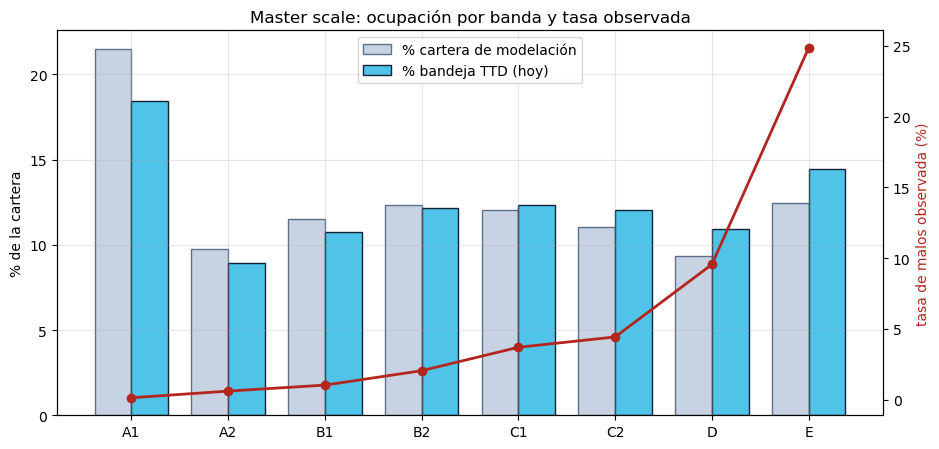

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
m_plot = master.iloc[::-1]
xs = np.arange(len(m_plot))
ax.bar(xs - 0.19, m_plot["pct_cartera"] * 100, width=0.38, color="#C7D2E3",
       edgecolor="#5E708A", label="% cartera de modelación")
ax.bar(xs + 0.19, m_plot["pct_ttd"] * 100, width=0.38, color="#4FC3E8",
       edgecolor="#122035", label="% bandeja TTD (hoy)")
ax.set_xticks(xs); ax.set_xticklabels(m_plot.index)
ax.set_ylabel("% de la cartera"); ax.legend(loc="upper center")
ax2 = ax.twinx()
ax2.plot(xs, m_plot["tasa_observada"] * 100, color="#B3261E", marker="o", lw=2)
ax2.set_ylabel("tasa de malos observada (%)", color="#B3261E")
ax2.grid(False)
ax.set_title("Master scale: ocupación por banda y tasa observada")
plt.tight_layout(); plt.show()

**Tres lecturas para el comité:**

1. **Monotonía impecable**: 0,14% (A1) → 24,9% (E). La escala separa de verdad.
2. **Ocupación repartida**: ninguna banda pasa del 22% de la cartera.
3. **La bandeja TTD pesa más en D y E** que la cartera de desarrollo (14,5% vs
   12,5% en E): el flujo de hoy viene más riesgoso. Primer aviso de deriva — el
   PSI del score (clase 5) le pondrá número y semáforo.

> 🏦 En una institución real, la master scale es **corporativa** (una sola para
> todos los modelos) y cada scorecard se mapea a ella. La nuestra es del curso,
> pero la mecánica es idéntica.

---
## 7. La tabla de estrategia: aprobación vs pérdida esperada

El cutoff es una **decisión comercial informada por riesgo**: el modelo pone la
curva, el negocio elige el punto. Nuestra evidencia: para cada cutoff candidato,
¿cuánto apruebo, cuánta mora acepto, cuánta plata espero perder?

Para hablar de plata necesitamos la **pérdida esperada**:

$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

Convenciones de hoy, **declaradas**: LGD = 45% (consumo sin garantía, convención
de industria — en rigor se modela aparte) y EAD = monto solicitado. Y todo se
mide sobre **OOT**: la muestra con desempeño más parecida a la cartera que viene
(medirlo en DEV sería auto-complacencia).

In [14]:
LGD = 0.45
oot_e = oot.copy()
oot_e["pd_cal"] = PD_CAL["OOT"]
oot_e["score_cal"] = SCORE_CAL["OOT"]
monto = oot_e["monto_solicitado"].astype(float)

filas = []
for c in range(500, 641, 20):
    ap = oot_e["score_cal"] >= c
    if ap.sum() == 0:
        continue                      # un cutoff que no aprueba a nadie no es una política
    el_pesos = float((oot_e.loc[ap, "pd_cal"] * LGD * monto[ap]).sum())
    filas.append({"cutoff": c,
                  "aprobacion": ap.mean(),
                  "mora_aprobados": oot_e.loc[ap, "malo"].mean(),
                  "pd_cal_aprobados": oot_e.loc[ap, "pd_cal"].mean(),
                  "monto_aprobado_MM": monto[ap].sum() / 1e6,
                  "EL_MM": el_pesos / 1e6,
                  "EL_sobre_monto": el_pesos / monto[ap].sum()})
estrategia = pd.DataFrame(filas).set_index("cutoff")
print(estrategia.round(4).to_string())

        aprobacion  mora_aprobados  pd_cal_aprobados  monto_aprobado_MM     EL_MM  EL_sobre_monto
cutoff                                                                                           
500         0.9775          0.0490            0.0453            5966.40  122.0291          0.0205
520         0.9476          0.0421            0.0373            5776.46   95.7799          0.0166
540         0.8688          0.0316            0.0244            5315.29   58.3080          0.0110
560         0.7829          0.0210            0.0159            4796.83   34.3606          0.0072
580         0.6732          0.0178            0.0096            4145.03   18.6166          0.0045
600         0.5539          0.0144            0.0056            3375.10    8.8188          0.0026
620         0.4366          0.0091            0.0034            2620.22    4.0400          0.0015
640         0.3149          0.0063            0.0019            1881.36    1.6388          0.0009


**Cómo se lee esta tabla en un comité** (cada fila es una política posible):

- **Cutoff 540**: aprueba 86,9% con mora 3,16% y EL 1,10% del monto.
- **Cutoff 560**: aprueba 78,3% con mora 2,10% y EL 0,72%. El salto 520 → 560
  deja de aprobar ~16% del flujo y **la mora de la cartera cae a la mitad**.
- **Cutoff 580**: aprueba 67,3% con mora 1,78% y EL 0,45% — el punto defensivo.

La **recomendación del equipo modelador** (se argumenta, no se impone): cutoff
**560** — mora **observada** en OOT 2,10% (la esperada por PD calibrada: 1,59%)
contra el 4,48% de la política asumida, cediendo 12 puntos de aprobación. Si
comercial no cede volumen, la siguiente sección muestra la alternativa:
**igual aprobación, ~22% menos de mora** (con la letra chica que ahí se declara).

> ⚠️ El error clásico que la pauta de la E2 castiga: elegir cutoff mirando el
> Gini, o construir esta tabla sobre DEV. La estrategia se decide sobre OOT.

---
## 8. Swap-set: a quién apruebo que antes rechazaba

La pregunta que el comité siempre hace: cambiar de política **intercambia
clientes concretos**. ¿Quiénes entran, quiénes salen, y qué tan buenos/malos
son unos y otros?

La política vigente del Banco Austral (asumida para la demo): **knock-outs
duros** — se rechaza a quien tiene mora interna vigente (`dias_mora_ult > 0`) o
mora relevante en el sistema (`peor_mora_sistema_ult ≥ 30`). Ambas son fotos a
$t_0-1$: información disponible al decidir, sin fuga.

Para aislar el efecto **puro** del modelo, el swap-set se arma a **igual tasa de
aprobación**: si la política vigente aprueba $k$ créditos, el scorecard aprueba
sus $k$ mejores scores, y cruzamos las dos decisiones sobre OOT.

> 🔧 Detalle de implementación que importa: un cuantil interpolado **no**
> garantiza el mismo $k$ si hay scores empatados en el umbral. Por eso se
> seleccionan los $k$ mejores directamente (con desempate estable) y el "cutoff
> equivalente" que se reporta es el score del $k$-ésimo aprobado.

In [15]:
rechaza_vieja = (oot_e["dias_mora_ult"] > 0) | (oot_e["peor_mora_sistema_ult"] >= 30)
aprueba_vieja = ~rechaza_vieja
tasa_aprob = float(aprueba_vieja.mean())

# los k mejores scores, con desempate estable (un cuantil no garantiza igual n)
k = int(aprueba_vieja.sum())
orden_sc = np.argsort(-oot_e["score_cal"].to_numpy(), kind="stable")
marca_nueva = np.zeros(len(oot_e), dtype=bool)
marca_nueva[orden_sc[:k]] = True
aprueba_nueva = pd.Series(marca_nueva, index=oot_e.index)
cutoff_equiv = float(oot_e["score_cal"].to_numpy()[orden_sc[k - 1]])
assert int(aprueba_nueva.sum()) == k, "el swap no quedó a igual aprobación"
print(f"política vigente: aprueba {tasa_aprob:.1%} ({k:,} créditos) · "
      f"cutoff equivalente del scorecard: {cutoff_equiv:.0f}")

celdas = {"ambas aprueban":  aprueba_vieja & aprueba_nueva,
          "swap-in (entra)": ~aprueba_vieja & aprueba_nueva,
          "swap-out (sale)": aprueba_vieja & ~aprueba_nueva,
          "ambas rechazan":  ~aprueba_vieja & ~aprueba_nueva}
swap = pd.DataFrame({nombre_c: {"n": int(m.sum()), "pct": m.mean(),
                                "tasa_malos": (oot_e.loc[m, "malo"].mean()
                                               if m.any() else np.nan)}
                     for nombre_c, m in celdas.items()}).T
print("\n" + swap.round(4).to_string())

t_vieja = oot_e.loc[aprueba_vieja, "malo"].mean()
t_nueva = oot_e.loc[aprueba_nueva, "malo"].mean()
print(f"\ncartera aprobada — mora política vigente: {t_vieja:.2%} · "
      f"scorecard al mismo volumen: {t_nueva:.2%} ({t_nueva / t_vieja - 1:+.0%})")
if int(swap.loc["swap-in (entra)", "n"]) > 0:
    assert swap.loc["swap-in (entra)", "tasa_malos"] < swap.loc["swap-out (sale)", "tasa_malos"]
    print("✅ el que entra es mejor que el que sale: el intercambio conviene")
else:
    print("(las dos políticas aprueban exactamente a los mismos: no hay swap que evaluar)")

política vigente: aprueba 90.2% (1,808 créditos) · cutoff equivalente del scorecard: 533

                      n     pct  tasa_malos
ambas aprueban   1680.0  0.8383      0.0304
swap-in (entra)   128.0  0.0639      0.0938
swap-out (sale)   128.0  0.0639      0.2344
ambas rechazan     68.0  0.0339      0.3824

cartera aprobada — mora política vigente: 4.48% · scorecard al mismo volumen: 3.48% (-22%)
✅ el que entra es mejor que el que sale: el intercambio conviene


**La lectura ejecutiva** (misma tasa de aprobación — el 90,2% de las
cursadas OOT que la política asumida aprueba):

- **Swap-in**: 128 créditos que el score aprueba y los knock-outs asumidos
  rechazaban — tasa de malos **9,4%**.
- **Swap-out**: 128 créditos que los knock-outs aprobaban y el score rechaza —
  tasa de malos **23,4%**.
- Resultado neto: la mora de la cartera aprobada cae de **4,48% a 3,48%** (−22%)
  sin ceder un punto de aprobación.

**La letra chica, ANTES de que la levante el comité:** esto es un *challenger
retrospectivo sobre las cursadas* — todos estos créditos fueron aprobados por el
banco real (por eso tienen desempeño observable) y el ejercicio **reemplaza** la
política de knock-outs por el score. Los rechazados reales del banco no están en
la mesa: ese territorio es el de la sección 9.

Dos matices que un comité fino va a levantar (y sus respuestas):

1. *«El swap-in trae 9,4% — el triple de la cartera actual.»* Cierto, pero el
   número relevante es el **23,4% del swap-out que suelta**: el intercambio es
   1:1 y el neto es −22% de mora.
2. *«¿Y los knock-outs quedan obsoletos?»* No: los que **ambas** rechazan traen
   38,2% de malos. Las reglas duras no estaban locas — eran **insuficientes**.
   En producción suelen convivir (knock-outs primero, score después) — y ojo:
   esa política combinada NO es la de este ejercicio, que midió el reemplazo
   puro; si los KO siguen vinculantes, el swap-in no entra y la ganancia es
   menor. La decisión reemplazo-vs-combinación es del comité, con este cuadro
   sobre la mesa.

> ⚖️ Ojo con la letra chica del swap-in: son clientes de un territorio donde el
> modelo tiene **poca o ninguna evidencia propia**. Eso nos lleva directo a la
> última confesión del curso…

---
## 9. Reject inference: la puerta completa

Todo lo que hemos modelado usa **cursadas** — solicitudes aprobadas, con
desempeño observable. Pero ¿cuánto es eso de la puerta completa?

In [16]:
total = len(solicitudes)
aprobadas = int(solicitudes["aprobada"].sum())
maduras = int((solicitudes["aprobada"]
               & (solicitudes["fecha_solicitud"] <= "2025-06")).sum())
print(f"solicitudes históricas del Banco Austral : {total:,}".replace(",", "."))
print((f"aprobadas (solo ellas llegan a observarse): {aprobadas:,} "
       f"({aprobadas / total:.1%})").replace(",", "."))
print(f"   … y con ventana de 12 meses ya madura  : {maduras:,}".replace(",", "."))
print((f"rechazadas (SIN desempeño — jamás)        : {total - aprobadas:,} "
       f"({1 - aprobadas / total:.1%})").replace(",", "."))

solicitudes históricas del Banco Austral : 32.301
aprobadas (solo ellas llegan a observarse): 21.613 (66.9%)
   … y con ventana de 12 meses ya madura  : 12.530
rechazadas (SIN desempeño — jamás)        : 10.688 (33.1%)


**Un tercio de la puerta no tiene desempeño.** El modelo aprendió «cómo se
comportan los que el proceso anterior dejó pasar» — y cuando el cutoff nuevo
entra a territorio antes rechazado (el swap-in de la sección 8), ahí
**extrapola**.

**Reject inference** es la familia de técnicas que intenta atribuir desempeño
inferido a los rechazados (*augmentation*, *parceling*, *fuzzy augmentation*).
Todas descansan en supuestos fuertes que no se pueden verificar con los datos
que las motivan — por eso exigen validación aparte y mucha humildad.

**La decisión honesta de este curso: no lo hacemos, y lo declaramos.** En el
informe técnico de su proyecto va una limitación explícita: *«el modelo se
desarrolló sobre solicitudes aprobadas (67% de la puerta); su desempeño en
población históricamente rechazada no está validado»*.

Y la práctica responsable cuando la política nueva abre la puerta:
- partir **conservador** en el territorio nuevo (cutoff más exigente o cupos menores),
- monitorear el swap-in como **cohorte aparte** desde el día uno,
- **recalibrar** con la evidencia real que esa cohorte genere.

> 🧭 Desconfíen de un scorecard de admisión que no diga en qué población NO
> sabe. El nuestro lo dice — y eso lo hace más defendible, no menos.

---
## 10. El atajo que NO existe (y el que viene)

La pregunta natural después de la clase 3: ¿y el paso *calibración* de la
herramienta? La respuesta honesta: **la calibración no tiene atajo**, porque su
insumo crítico no es código — es la **decisión de negocio** del ancla. La
mecánica completa de hoy son ~10 líneas (una tabla de cosechas, un promedio,
un `brentq`); lo difícil fue decidir **qué TC declarar y por qué**, y eso no
viene en ninguna caja:

- `optbinning` (nuestra pista industrial de las clases 2 y 3) escala puntos con
  la convención PDO — pero **no decide anclas**: no sabe si tu ventana cubre
  ciclo ni qué dijo el comité.
- Los pipelines industriales (lo veremos **end-to-end en la clase 6**) sí
  ejecutan este paso — y su valor no es la ecuación, sino que el ancla viaja
  **declarada en un config auditable**: TC, fuente, método y δ resultante
  quedan registrados, no en la memoria del modelador.

**Lo que ninguna herramienta decide por ustedes** — y es la moraleja de la
clase: la TC (la fija el negocio), la master scale (diseño de gobierno), el
cutoff (comité) y el swap-set (análisis de política). Las herramientas
industrializan la **mecánica**; la **estrategia** sigue siendo de quien firma.

---
## Cierre: qué construimos hoy

**La cadena completa, con los números del Banco Austral:**

| Pieza | Resultado |
|---|---|
| Diagnóstico de nivel | DEV clava (por construcción) · HO −0,42 · OOT −0,75 pts |
| Tendencia central | 5,42% (promedio simple de 12 cosechas; se declara) |
| Ajuste de intercepto | δ exacto +0,112 (aprox. +0,092) · ranking intacto |
| Nivel calibrado | HO +0,05 · OOT −0,29 pts (residuo: ¿deriva? — hipótesis a C5) |
| Master scale | 8 bandas de 20 pts · monótona 0,14% → 24,9% · TTD cargado a D/E |
| Estrategia (OOT, LGD 45%) | 560 → aprueba 78,3%, mora 2,10%, EL 0,72% del monto |
| Swap-set (@ 90,2% aprobación) | entra 9,4% / sale 23,4% → mora 4,48% → 3,48% |
| Reject inference | 33,1% de la puerta sin desempeño — limitación declarada |

**Nos vemos el jueves 10 (clase 5):** ¿cómo sé que todo
esto **sigue** siendo verdad en producción? AUC/Gini/KS con intervalos, PSI del
score, CSI, backtesting de calibración y el tablero de monitoreo con semáforos.

### Para el comité (los 3 mensajes de hoy)

1. **Ranking y nivel son promesas distintas.** El Gini no defiende una provisión:
   la defiende una PD calibrada contra una tendencia central con dueño y fecha.
2. **El cutoff es una decisión comercial informada por riesgo.** La tabla de
   estrategia y el swap-set — medidos fuera del desarrollo — son la evidencia
   mínima para firmarla.
3. **Digan dónde el modelo no sabe.** Un tercio de la puerta nunca tuvo
   desempeño; declararlo (y monitorear el swap-in como cohorte) es lo que
   separa un modelo defendible de uno maquillado.